In [37]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

In [5]:
df = pd.read_csv(r"C:\Users\asifb\OneDrive\Desktop\Python language\Jupyter Notebook\Kaggle\Wine .csv")
df.sample(4)

,age,gender,fever,cough,city,has_covid
20,12,Male,98.0,Strong,Bangalore,No
41,82,Male,NaN,Mild,Kolkata,Yes
77,8,Female,101.0,Mild,Kolkata,No
69,73,Female,103.0,Mild,Delhi,No


In [15]:
df.info()

<class 'pandas.DataFrame'>
Index: 90 entries, 0 to 99
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        90 non-null     int64  
 1   gender     90 non-null     str    
 2   fever      90 non-null     float64
 3   cough      90 non-null     str    
 4   city       90 non-null     str    
 5   has_covid  90 non-null     str    
dtypes: float64(1), int64(1), str(4)
memory usage: 4.9 KB


In [12]:
df.isnull().sum()

age          0
gender       0
fever        0
cough        0
city         0
has_covid    0
dtype: int64

In [11]:
df = df.dropna()

In [14]:
df.shape

(90, 6)

In [18]:
df = pd.read_excel(r"C:\Users\asifb\OneDrive\Desktop\Python language\Jupyter Notebook\Kaggle\Data Science Jobs.xlsx")
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0,1
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0,0


In [24]:
df.isnull().mean()*100    # this tells the percentage of missing data in each column 

enrollee_id                0.000000
city                       0.000000
city_development_index     2.500261
gender                    23.530640
relevent_experience        0.000000
enrolled_university        2.014824
education_level            2.401086
major_discipline          14.683161
experience                 0.339284
company_size              30.994885
company_type              32.049274
training_hours             3.998330
target                     0.000000
dtype: float64

In [25]:
df.shape

(19158, 13)

In [26]:
col = []
for var in df.columns:
    if df[var].isnull().mean() < 0.05 and df[var].isnull().mean() > 0:
        col.append(var)

In [30]:
df1 = df[col]
df1.head()

,city_development_index,enrolled_university,education_level,experience,training_hours
0,0.920,no_enrollment,Graduate,20.0,36.0
1,0.776,no_enrollment,Graduate,15.0,47.0
2,0.624,Full time course,Graduate,5.0,83.0
3,0.789,NaN,Graduate,0.0,52.0
4,0.767,no_enrollment,Masters,20.0,8.0


In [33]:
len(df1.dropna())/len(df)

0.8968577095730244

In [34]:
df1 = df1.dropna()
df1.shape , df.shape

((17182, 5), (19158, 13))

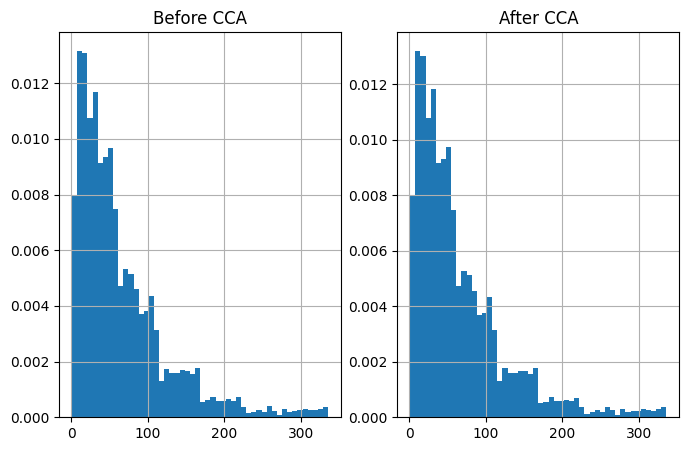

In [70]:
plt.figure(figsize = (8,5))
plt.subplot(1,2,1)
# Original Data
df["training_hours"].hist(bins = 50 , density = True)
plt.title("Before CCA")

# After CCA
plt.subplot(1,2,2)
df1["training_hours"].hist(bins = 50 , density = True)
plt.title("After CCA")
plt.show()

<Axes: >

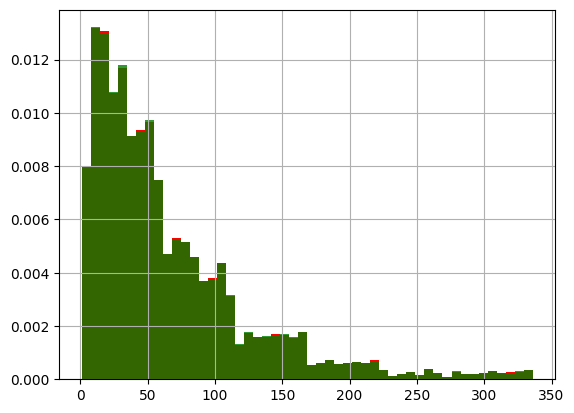

In [44]:
fig = plt.figure()       # density true because on default hist shows count and we have deleted some rows so comparing both would be irrelevant as 
                         # df1 has less rows so we did this to get propotional numbers not row count, alpha is use for color shade alpha = 0 means 
                          # fully invisible 
ax = fig.add_subplot(111)    # one histogram with two data sets 

# original data
df['training_hours'].hist(bins=50, ax=ax, density=True, color='red')

# data after cca, the argument alpha makes the color transparent, so we can# see the overlay of the 2 distributions
df1['training_hours'].hist(bins=50, ax=ax, color='green', density=True, alpha=0.8)

In [47]:
df.columns , df1.columns 

(Index(['enrollee_id', 'city', 'city_development_index', 'gender',
        'relevent_experience', 'enrolled_university', 'education_level',
        'major_discipline', 'experience', 'company_size', 'company_type',
        'training_hours', 'target'],
       dtype='str'),
 Index(['city_development_index', 'enrolled_university', 'education_level',
        'experience', 'training_hours'],
       dtype='str'))

<Axes: >

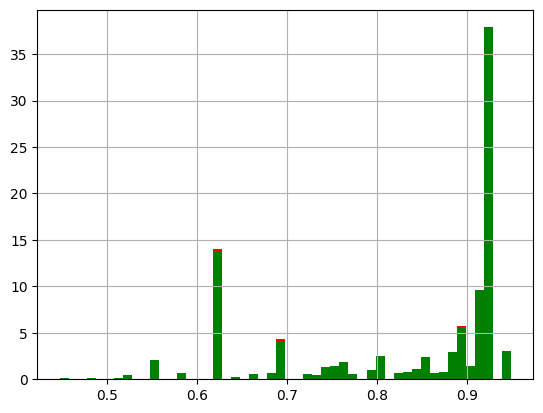

In [52]:
fig = plt.figure()
ax = fig.add_subplot(111)

df["city_development_index"].hist(bins = 50,density = True , ax= ax , color = "red")

df1["city_development_index"].hist(bins = 50 , density = True, ax = ax , color = "green" )

In [55]:
df["education_level"].value_counts()/len(df["education_level"])

education_level
Graduate          0.605387
Masters           0.227633
High School       0.105282
Phd               0.021610
Primary School    0.016077
Name: count, dtype: float64

In [56]:
df1["education_level"].value_counts()/len(df1["education_level"])

education_level
Graduate          0.619835
Masters           0.234082
High School       0.107380
Phd               0.022116
Primary School    0.016587
Name: count, dtype: float64

In [62]:
df3 = pd.concat([
df["education_level"].value_counts()/len(df["education_level"]) , df1["education_level"].value_counts()/len(df1["education_level"])
    
], axis = 1)
df3.columns = ["Before CCA" , "After CCA"]
df3

# we have to keep ratios same after CCA 

,Before CCA,After CCA
education_level,,
Graduate,0.605387,0.619835
Masters,0.227633,0.234082
High School,0.105282,0.107380
Phd,0.021610,0.022116
Primary School,0.016077,0.016587


In [64]:
df1.head()

,city_development_index,enrolled_university,education_level,experience,training_hours
0,0.920,no_enrollment,Graduate,20.0,36.0
1,0.776,no_enrollment,Graduate,15.0,47.0
2,0.624,Full time course,Graduate,5.0,83.0
4,0.767,no_enrollment,Masters,20.0,8.0
5,0.764,Part time course,Graduate,11.0,24.0


In [67]:
df1["enrolled_university"].value_counts()/ len(df1)

enrolled_university
no_enrollment       0.735188
Full time course    0.200733
Part time course    0.064079
Name: count, dtype: float64

In [69]:
df4 = pd.concat([
df["enrolled_university"].value_counts()/ len(df) , df1["enrolled_university"].value_counts()/ len(df1)
], axis = 1)

df4.columns = ["Before CCA" , "After CCA"]
df4


,Before CCA,After CCA
enrolled_university,,
no_enrollment,0.721213,0.735188
Full time course,0.196106,0.200733
Part time course,0.062533,0.064079


In [71]:
df4 = pd.concat([
df["city_development_index"].value_counts()/ len(df) , df1["city_development_index"].value_counts()/ len(df1)
], axis = 1)

df4.columns = ["Before CCA" , "After CCA"]
df4


,Before CCA,After CCA
city_development_index,,
0.920,0.265059,0.277733
0.624,0.136705,0.137760
0.910,0.078401,0.081364
0.926,0.067700,0.069200
0.698,0.034659,0.033058
...,...,...
0.649,0.000209,0.000175
0.807,0.000209,0.000233
0.781,0.000157,0.000175
